# ABSA Model Comparison

Methodology based on *Gonçalves et al. "Comparing and combining sentiment analysis methods" (COSN 2013)*:
1. **Prediction performance** — Precision, Recall, F1, Accuracy
2. **F1 per aspect** — heatmaps (4-class and mentioned-only)
3. **Agreement** — inter-method agreement matrix
4. **Coverage** — fraction of predictions != notmentioned
5. **Confusion matrices** — row-normalized with cost analysis

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

from config.global_config import TRAIN_ASPECTS, SENTIMENT_LABELS, ModelType
from predictions.eval_align import narrow_eval_to_common_rows
from predictions.labeled_csv import read_labeled_reviews_csv
from predictions.predict_dataset import model_cache, predict_dataset

ASPECTS = TRAIN_ASPECTS
LABELS  = SENTIMENT_LABELS
SHORT   = ["pos", "neu", "neg", "n/m"]
SENT_3  = [l for l in LABELS if l != "notmentioned"]

CACHE_DIR = Path("statics/prediction_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
TEST_PATH = "statics/datasets/validate.csv"


def flat(df):
    """Flatten aspect columns into a single label vector."""
    return np.concatenate([
        df[a].replace("", np.nan).fillna("notmentioned").astype(str).to_numpy()
        for a in ASPECTS
    ])

/Users/bartoszbugla/projects/projekt-magisterski/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load ground truth

In [2]:
df = read_labeled_reviews_csv(TEST_PATH)
for a in ASPECTS:
    df[a] = df[a].fillna("notmentioned")

gt = df[["text"] + ASPECTS].copy()
print(f"{len(gt)} reviews x {len(ASPECTS)} aspects = {len(gt) * len(ASPECTS)} labels")
gt[ASPECTS].apply(pd.Series.value_counts).T.fillna(0).astype(int).reindex(columns=LABELS)

1191 reviews x 8 aspects = 9528 labels


,positive,neutral,negative,notmentioned
safety,23,10,30,1128
cleanliness,50,5,24,1112
infrastructure,153,35,89,914
nature,236,18,13,924
attractions,421,25,40,705
heritage,135,20,13,1023
costs,51,13,58,1069
other,604,137,111,338


## Run predictions (with disk cache)

In [ ]:
model_cache.clear()

REPO_ROOT = Path.cwd()
_CHECKPOINTS = {
    ModelType.FINE_TUNED_BERT:          REPO_ROOT / "saved_models" / "bert-base-uncased_absa.pt",
    ModelType.FINE_TUNED_DISTILBERT:    REPO_ROOT / "saved_models" / "distilbert-base-uncased_absa.pt",
    ModelType.FINE_TUNED_DISTILBERT_SST: REPO_ROOT / "saved_models" / "distilbert-base-uncased-finetuned-sst-2-english_absa.pt",
    ModelType.TEST_BERT_BASE_UNCASED_ABSA: REPO_ROOT / "saved_models" / "distilbert-base-uncased-finetuned-sst-2-english_test_absa.pt",
}

METHODS = {
    "DistilBERT-SST": (ModelType.FINE_TUNED_DISTILBERT_SST, False),
    "BERT":           (ModelType.FINE_TUNED_BERT, False),
    "TF-IDF + LR":    (ModelType.TFIDF_LSA, False),
}


def _cached(key, use_disk, factory):
    path = CACHE_DIR / f"{key}.csv"
    if use_disk and path.is_file():
        return pd.read_csv(path)
    out = factory()
    out.to_csv(path, index=False)
    return out


preds = {}
base = gt.drop(columns=ASPECTS, errors="ignore")

for name, (mtype, use_disk) in METHODS.items():
    ckpt = _CHECKPOINTS.get(mtype)
    if ckpt and not ckpt.is_file():
        warnings.warn(f'Skipping "{name}": checkpoint not found at {ckpt}')
        continue
    key = f"{mtype.value}_{name.replace(' ', '_')}"
    preds[name] = _cached(key, use_disk, lambda mt=mtype: predict_dataset(base.copy(), mt, on_progress=None))

if not preds:
    raise RuntimeError("No predictions — add at least one checkpoint under saved_models/.")

gt, preds = narrow_eval_to_common_rows(gt, preds)

majority = pd.DataFrame({"text": gt["text"].values})
for a in ASPECTS:
    majority[a] = gt[a].value_counts().idxmax()
preds["Majority"] = majority

print(f"Methods: {list(preds.keys())}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12309.40it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using device: mps
Using devi

## 1. Overall performance

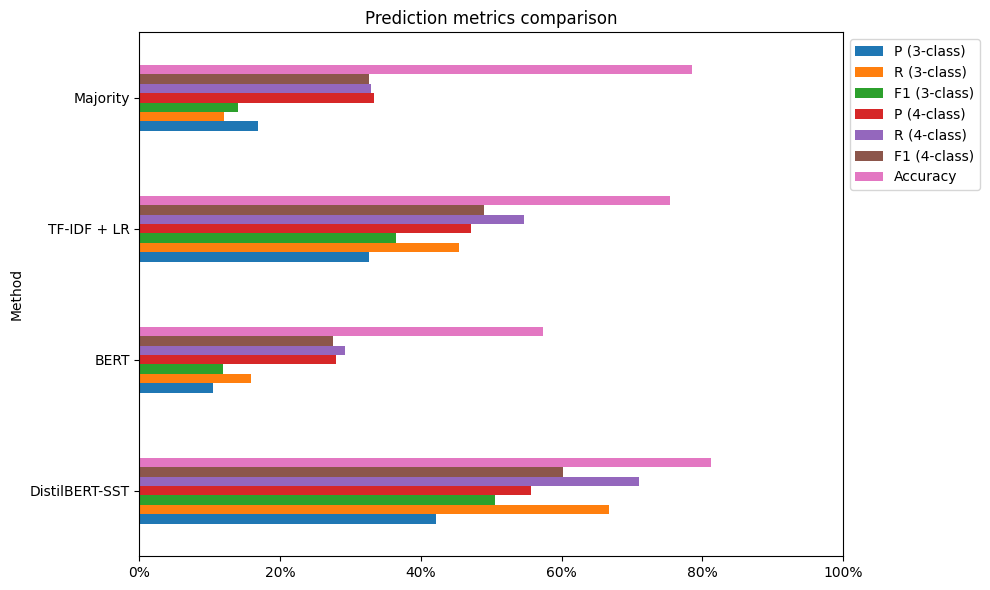

,P (3-class),R (3-class),F1 (3-class),P (4-class),R (4-class),F1 (4-class),Accuracy
Method,,,,,,,
DistilBERT-SST,0.422,0.668,0.505,0.557,0.710,0.603,0.813
BERT,0.105,0.158,0.119,0.279,0.292,0.275,0.573
TF-IDF + LR,0.326,0.454,0.364,0.472,0.547,0.490,0.754
Majority,0.169,0.120,0.141,0.333,0.329,0.327,0.785


In [4]:
rows = []
for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    rows.append({
        "Method": name,
        "P (3-class)":  precision_score(yt, yp, labels=SENT_3, average="macro", zero_division=0),
        "R (3-class)":  recall_score(yt, yp, labels=SENT_3, average="macro", zero_division=0),
        "F1 (3-class)": f1_score(yt, yp, labels=SENT_3, average="macro", zero_division=0),
        "P (4-class)":  precision_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "R (4-class)":  recall_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "F1 (4-class)": f1_score(yt, yp, labels=LABELS, average="macro", zero_division=0),
        "Accuracy":     accuracy_score(yt, yp),
    })

perf = pd.DataFrame(rows).set_index("Method")

fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.5, 2)))
perf.plot.barh(ax=ax)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Prediction metrics comparison")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(perf.style.format("{:.3f}"))

## 2. Key metrics (imbalance-aware)

- **Detection F1** — binary mentioned vs notmentioned
- **Sentiment F1 (mentioned)** — macro F1 over pos/neu/neg, only where GT is mentioned
- **Coverage** — fraction of predictions != notmentioned

In [5]:
rows = []
for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    yt_bin = (yt != "notmentioned").astype(int)
    yp_bin = (yp != "notmentioned").astype(int)
    mask = yt != "notmentioned"

    rows.append({
        "Method": name,
        "Detection F1": f1_score(yt_bin, yp_bin, average="binary", zero_division=0),
        "Sentiment F1 (mentioned)": f1_score(yt[mask], yp[mask], labels=SENT_3, average="macro", zero_division=0) if mask.sum() else float("nan"),
        "Accuracy": accuracy_score(yt, yp),
        "Coverage": (yp != "notmentioned").mean(),
    })

summary = pd.DataFrame(rows).set_index("Method")
display(summary.style.format("{:.3f}"))

for name, p in preds.items():
    yt, yp = flat(gt), flat(p)
    print(f"\n=== {name} ===")
    print(classification_report(yt, yp, labels=LABELS, digits=3, zero_division=0))

,Detection F1,Sentiment F1 (mentioned),Accuracy,Coverage
Method,,,,
DistilBERT-SST,0.747,0.675,0.813,0.346
BERT,0.382,0.198,0.573,0.343
TF-IDF + LR,0.650,0.497,0.754,0.312
Majority,0.487,0.159,0.785,0.125



=== DistilBERT-SST ===
              precision    recall  f1-score   support

    positive      0.688     0.797     0.738      1673
     neutral      0.219     0.540     0.312       263
    negative      0.357     0.667     0.465       378
notmentioned      0.965     0.834     0.895      7213

   micro avg      0.813     0.813     0.813      9527
   macro avg      0.557     0.710     0.603      9527
weighted avg      0.871     0.813     0.834      9527


=== BERT ===
              precision    recall  f1-score   support

    positive      0.221     0.223     0.222      1673
     neutral      0.052     0.175     0.080       263
    negative      0.042     0.077     0.054       378
notmentioned      0.800     0.695     0.744      7213

   micro avg      0.573     0.573     0.573      9527
   macro avg      0.279     0.292     0.275      9527
weighted avg      0.648     0.573     0.607      9527


=== TF-IDF + LR ===
              precision    recall  f1-score   support

    positive    

## 3. F1 per aspect

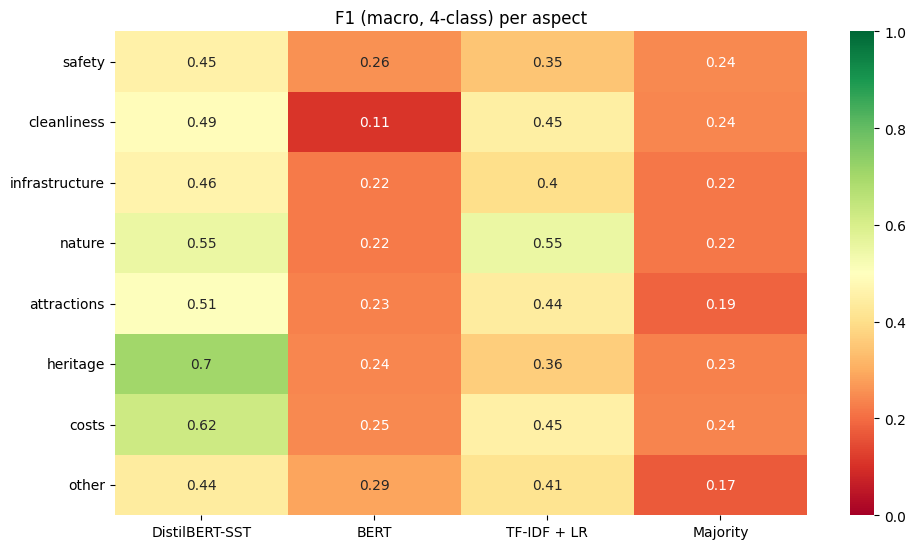

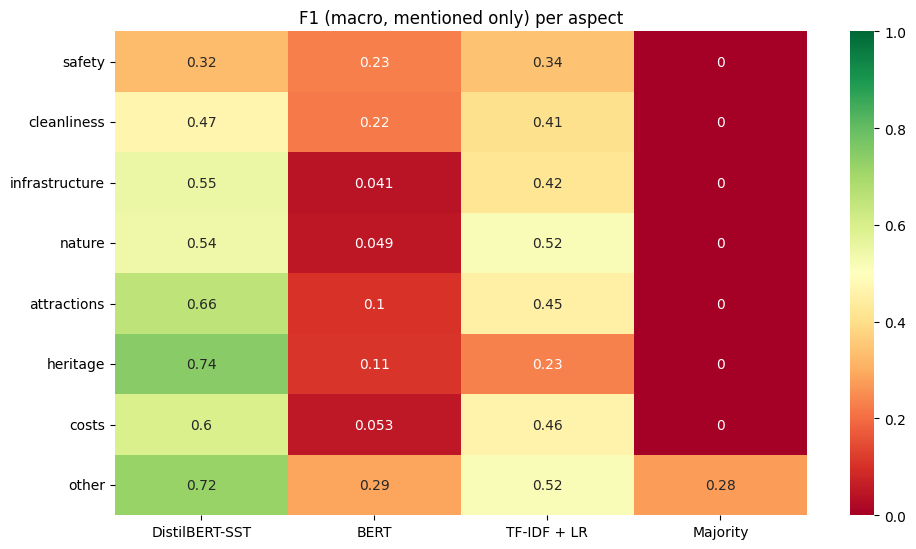

In [6]:
cmap = sns.color_palette("RdYlGn", as_cmap=True)

# 4-class F1 per aspect
f1_4 = pd.DataFrame({
    name: {a: f1_score(gt[a], p[a], labels=LABELS, average="macro", zero_division=0) for a in ASPECTS}
    for name, p in preds.items()
})
fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.4, 2.5)))
sns.heatmap(f1_4, annot=True, cmap=cmap, vmin=0, vmax=1, ax=ax)
ax.set_title("F1 (macro, 4-class) per aspect")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


# Mentioned-only F1 per aspect
def _f1_mentioned(yt, yp):
    mask = yt != "notmentioned"
    if mask.sum() == 0:
        return float("nan")
    return f1_score(yt[mask], yp[mask], labels=SENT_3, average="macro", zero_division=0)


f1_m = pd.DataFrame({
    name: {a: _f1_mentioned(gt[a].to_numpy().astype(str), p[a].to_numpy().astype(str)) for a in ASPECTS}
    for name, p in preds.items()
})
fig, ax = plt.subplots(figsize=(10, max(len(preds) * 1.4, 2.5)))
sns.heatmap(f1_m, annot=True, cmap=cmap, vmin=0, vmax=1, ax=ax)
ax.set_title("F1 (macro, mentioned only) per aspect")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Inter-method agreement

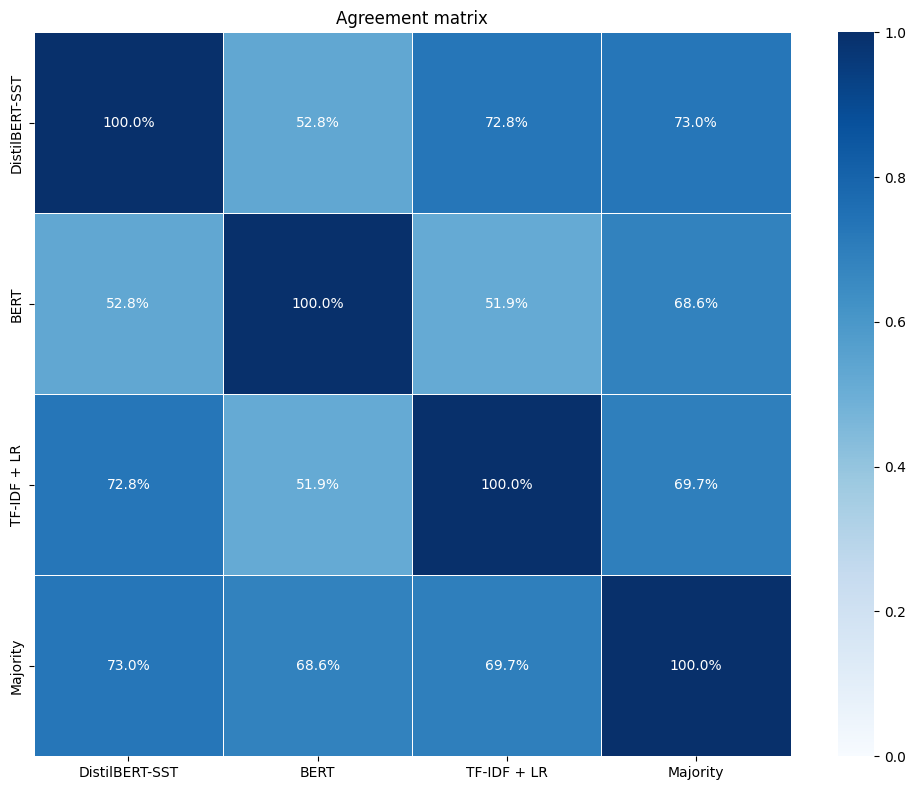

In [7]:
names = list(preds.keys())
agr = pd.DataFrame(
    [[(flat(preds[a]) == flat(preds[b])).mean() if i != j else 1.0
      for j, b in enumerate(names)]
     for i, a in enumerate(names)],
    index=names, columns=names,
)

fig, ax = plt.subplots(figsize=(max(len(names) * 2.5, 5), max(len(names) * 2, 4)))
sns.heatmap(agr, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1, linewidths=.5, ax=ax)
ax.set_title("Agreement matrix")
plt.tight_layout()
plt.show()

## 5. Coverage

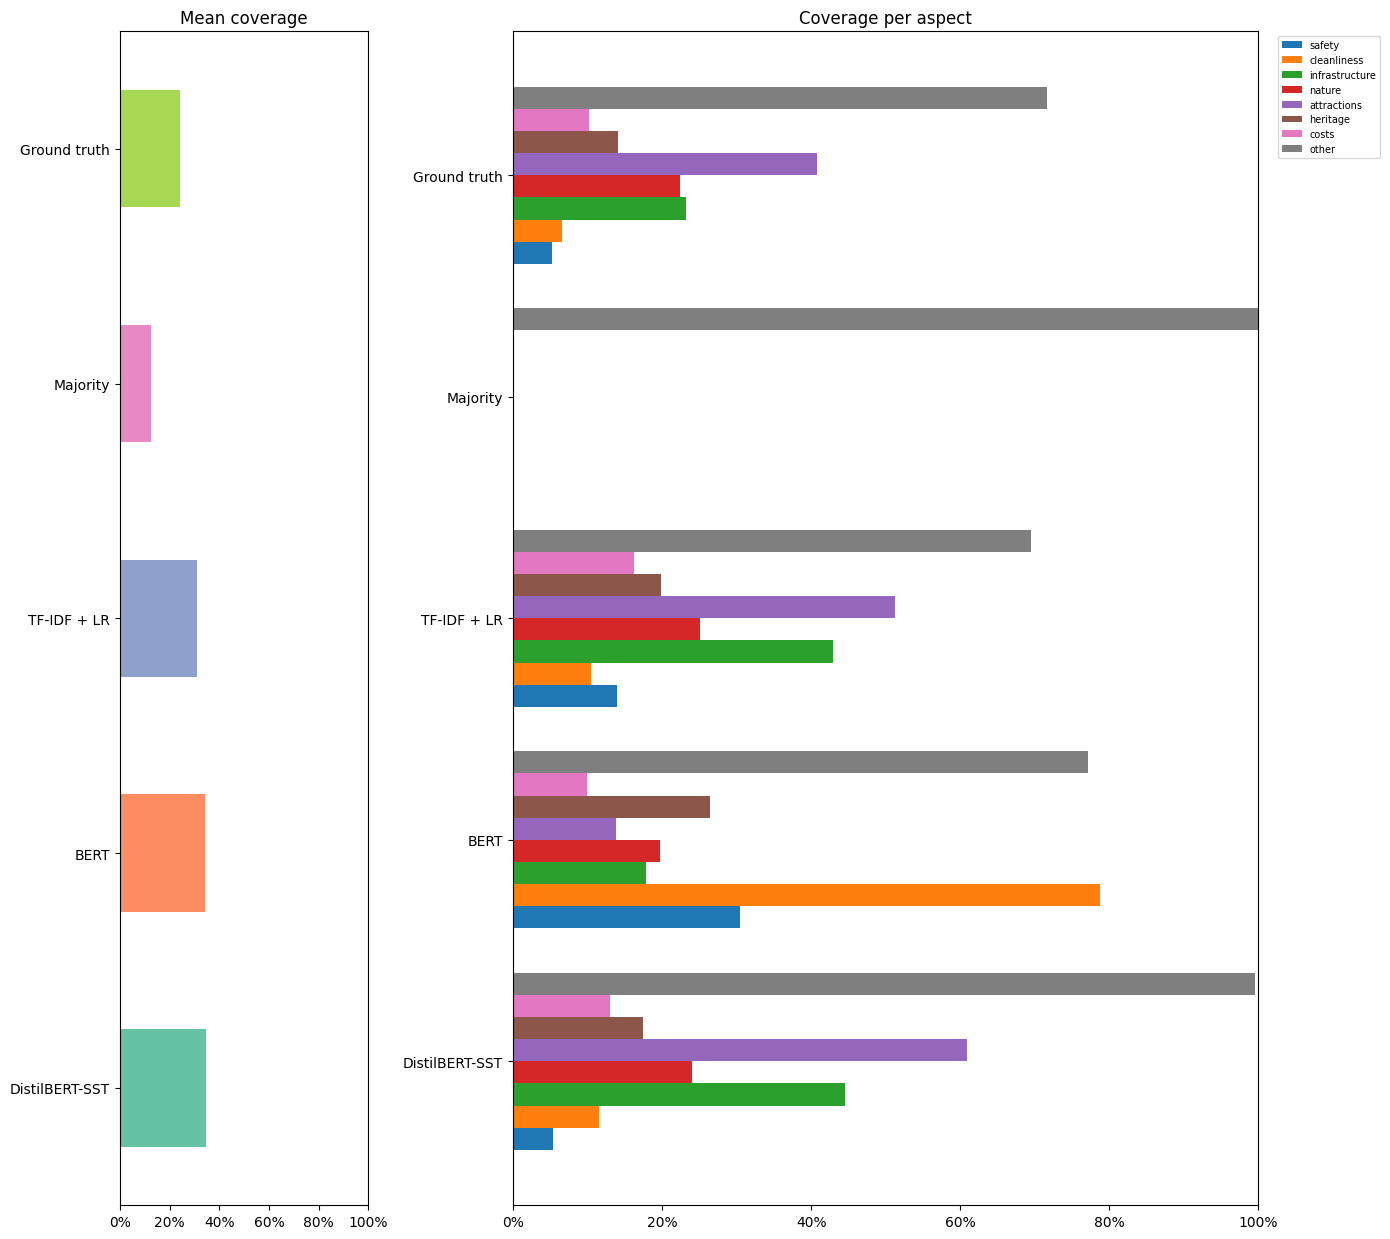

In [8]:
cov = pd.DataFrame(
    {n: {a: (p[a] != "notmentioned").mean() for a in ASPECTS} for n, p in preds.items()}
    | {"Ground truth": {a: (gt[a] != "notmentioned").mean() for a in ASPECTS}}
).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(len(cov) * 2.5, 3)), gridspec_kw={"width_ratios": [1, 3]})

cov.mean(axis=1).plot.barh(ax=ax1, color=sns.color_palette("Set2", len(cov)))
ax1.set_xlim(0, 1)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_title("Mean coverage")

cov.plot.barh(ax=ax2, width=0.8)
ax2.set_xlim(0, 1)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title("Coverage per aspect")
ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()

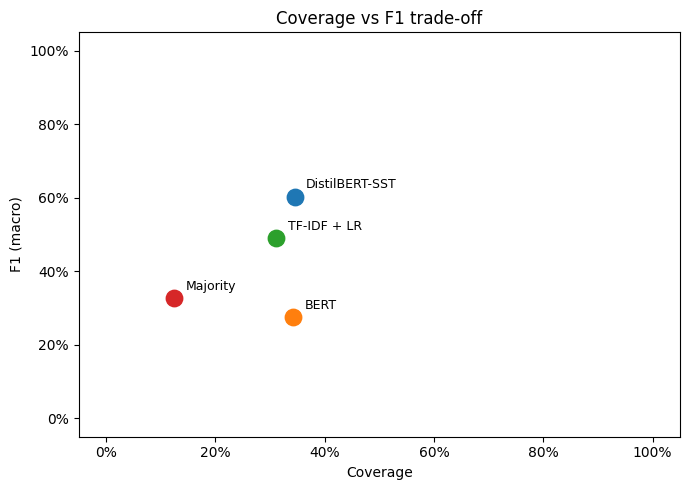

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for name in preds:
    yt, yp = flat(gt), flat(preds[name])
    f = f1_score(yt, yp, labels=LABELS, average="macro", zero_division=0)
    c = (yp != "notmentioned").mean()
    ax.scatter(c, f, s=140, zorder=5)
    ax.annotate(name, (c, f), textcoords="offset points", xytext=(8, 6), fontsize=9)

ax.set(xlabel="Coverage", ylabel="F1 (macro)", title="Coverage vs F1 trade-off")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## 6. Confusion matrices

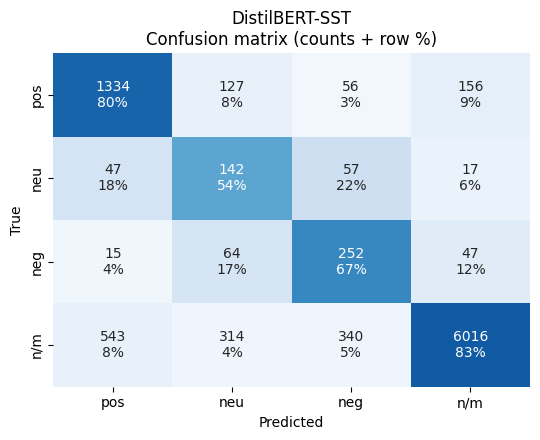

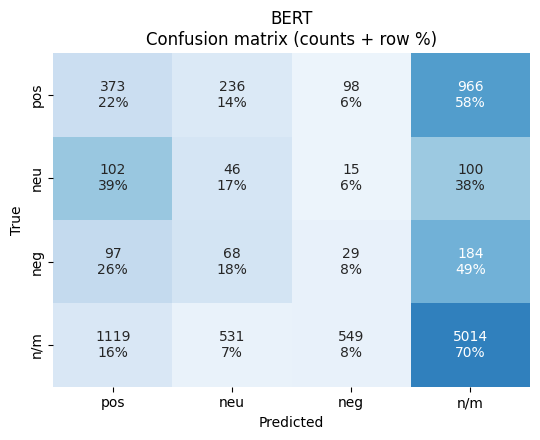

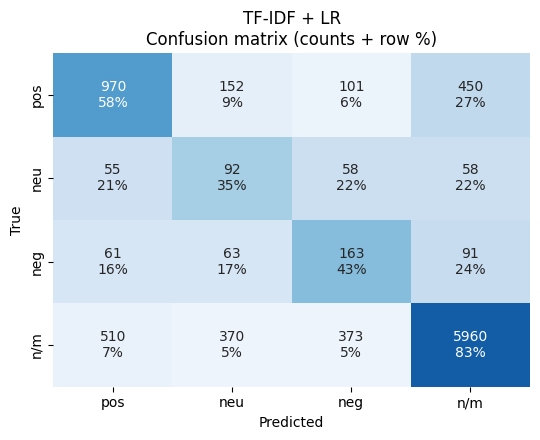

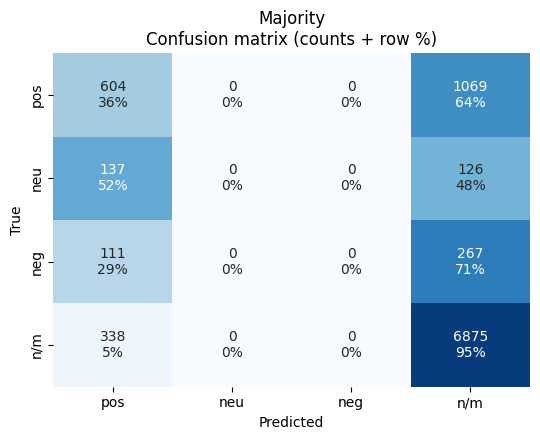

In [10]:
for name, p in preds.items():
    # Tworzymy osobną figurę dla każdej predykcji
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    yt, yp = flat(gt), flat(p)
    cm = confusion_matrix(yt, yp, labels=LABELS)
    rs = cm.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1
    cm_n = cm / rs

    annot = np.array([[f"{v}\n{p:.0%}" for v, p in zip(r, rn)] for r, rn in zip(cm, cm_n)])
    
    sns.heatmap(cm_n, annot=annot, fmt="", cmap="Blues", 
                xticklabels=SHORT, yticklabels=SHORT, ax=ax, vmin=0, vmax=1, cbar=False)
    
    # Ustawiamy tytuły i etykiety dla każdego wykresu niezależnie
    ax.set_title(f"{name}\nConfusion matrix (counts + row %)")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

    plt.tight_layout()
    plt.show() # Wyświetla obecny wykres przed przejściem do kolejnego